## **LIMPIEZA DE DATOS**

### 1.Problema Presentado
Una empresa global de servicios financieros lanzará una línea de crédito hipotecario, y se dispone de un presupuesto limitado para la adquisición de clientes. 
El costo operativo de contactar, verificar y procesar a cada cliente potencial mediante canales de telemarketing y pauta directa es de $2 USD por intento. 
Debido a esto, un despliegue masivo (Mass Marketing Campaign) sobre toda la base de datos sin segmentación previa generaría un déficit financiero inmediato y un desperdicio crítico de recursos presupuestarios en perfiles no elegibles.

Pain-Points: 
 - Degeneración de Datos: registros incompletos y formatos inconsistentes en la base demográfica.

 - Falta de Visibilidad del Perfil Socioeconómico: Ausencia de un diagnóstico claro sobre qué variables correlacionan con los altos ingresos.
 
 - Ausencia de un Tablero de Monitoreo de Pérdidas por Falsos Positivos: Inexistencia de métricas centralizadas para evaluar pérdidas financieras por Falsos Positivos.

In [1]:
#Importo Librerías
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
# Lectura del dataset
ruta = "C:/Users/Urano/OneDrive/Documentos/GitHub/Mi version de los TP/Adult Income/adult.csv"
data = pd.read_csv(ruta, na_values='?')

In [3]:
#Vemos las variables y el tipo de datos que contienen
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        46043 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       46033 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   47985 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [4]:
data.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,NaN,227026,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


Información General del Dataset:
  El registro contiene 14 caracteristicas y una categoría que determina el ingreso anual del cliente. 
  De las cuales 6 variables son Numéricas y 9 Categóricas. Las columnas son:

  - "age": Edad (numérica)
  - "workclass": Clase Trabajadora, Categórica ('Private', 'Local-gov', 'Self-emp-not-inc', 'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked')
  - "fnlwgt": Final Weight,proporción de la población total que comparte el mismo conjunto de características demográficas (Numérica) 
  - "education": Categórica ('11th', 'HS-grad', 'Assoc-acdm', 'Some-college', 10th',  'Prof-school', '7th-8th', 'Bachelors', 'Masters', 'Doctorate', '5th-6th', 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool')
  - "educational-num": Nivel educativo alcanzado representado en números.
  - "marital-status": Estado Civil, Categórica ('Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced', 'Separated, 'Married-spouse-absent', 'Married-AF-spouse')
  - "occupation": Cargo/Empleo, Categórica ('Machine-op-inspct', 'Farming-fishing', 'Protective-serv', 'Other-service', 'Prof-specialty', 'Craft-repair', 'Adm-clerical', 'Exec-managerial', 'Tech-support', 'Sales', 'Priv-house-serv', 'Transport-moving', 'Handlers-cleaners', 'Armed-Forces')
  - "relationship": Estado Civil Informal, Categórica ('Own-child', 'Husband', 'Not-in-family', 'Unmarried', 'Wife', 'Other-relative')
  - "race": Raza, Categórica ('Black', 'White', 'Asian-Pac-Islander', 'Other', 'Amer-Indian-Eskimo')
  - "gender": Genero, Categórica ('Male', 'Female')
  - "capital-gain": Ganancias en el aumento del valor de inversión de un activo a la hora de venderlo, Numérico.
  - "capital-loss": Perdida por la venta de un activo a un menor precio que el de costo, Numérico.
  - "hours-per-week": Horas Laborales acumuladas por Semana, Numérica
  - "native-country": País de Nacimiento, Categórica ('United-States', 'Peru', 'Guatemala', 'Mexico', 'Dominican-Republic', 'Ireland', 'Germany', 'Philippines', 'Thailand', 'Haiti', 'El-Salvador', 'Puerto-Rico', 'Vietnam', 'South', 'Columbia', 'Japan', 'India', 'Cambodia', 'Poland', 'Laos', 'England', 'Cuba', 'Taiwan', 'Italy', 'Canada', 'Portugal', 'China', 'Nicaragua', 'Honduras', 'Iran', 'Scotland', 'Jamaica', 'Ecuador', 'Yugoslavia', 'Hungary', 'Hong', 'Greece', 'Trinadad&Tobago', 'Outlying-US(Guam-USVI-etc)', 'France', 'Holand-Netherlands')
  - "Income": Ingreso Salarial medido por año, Categórica ('<=50K', '>50K')

In [5]:
columns_cat = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "gender", "native-country", "income"]

for col in columns_cat:
    print(f"Valores únicos: {data[col].unique()}")
    print("\n")

Valores únicos: <StringArray>
[         'Private',        'Local-gov',                nan,
 'Self-emp-not-inc',      'Federal-gov',        'State-gov',
     'Self-emp-inc',      'Without-pay',     'Never-worked']
Length: 9, dtype: str


Valores únicos: <StringArray>
[        '11th',      'HS-grad',   'Assoc-acdm', 'Some-college',
         '10th',  'Prof-school',      '7th-8th',    'Bachelors',
      'Masters',    'Doctorate',      '5th-6th',    'Assoc-voc',
          '9th',         '12th',      '1st-4th',    'Preschool']
Length: 16, dtype: str


Valores únicos: <StringArray>
[        'Never-married',    'Married-civ-spouse',               'Widowed',
              'Divorced',             'Separated', 'Married-spouse-absent',
     'Married-AF-spouse']
Length: 7, dtype: str


Valores únicos: <StringArray>
['Machine-op-inspct',   'Farming-fishing',   'Protective-serv',
                 nan,     'Other-service',    'Prof-specialty',
      'Craft-repair',      'Adm-clerical',   'Exec-manager

In [6]:
columns_cat = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "gender", "native-country", "income"]

for col in columns_cat:
    print(f"Valores únicos: {data[col].value_counts(dropna=False)}")
    print("\n")

Valores únicos: workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


Valores únicos: education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64


Valores únicos: marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64


Valores únicos: occupation
Pro

*Observaciones:*
 - Los valores faltantes se encuentran en las variables como '?' y no en celdas vacias como tal.

In [7]:
# - ELIMINACIÓN DE VALORES NULOS
data.dropna(inplace=True)
data.info()

<class 'pandas.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              45222 non-null  int64
 1   workclass        45222 non-null  str  
 2   fnlwgt           45222 non-null  int64
 3   education        45222 non-null  str  
 4   educational-num  45222 non-null  int64
 5   marital-status   45222 non-null  str  
 6   occupation       45222 non-null  str  
 7   relationship     45222 non-null  str  
 8   race             45222 non-null  str  
 9   gender           45222 non-null  str  
 10  capital-gain     45222 non-null  int64
 11  capital-loss     45222 non-null  int64
 12  hours-per-week   45222 non-null  int64
 13  native-country   45222 non-null  str  
 14  income           45222 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.5 MB


In [8]:
# BUSQUEDA DE COLUMNAS IRRELEVANTES, CON UNICOS VALORES O CON INFORMACIÓN IRRELEVANTE (std=0)
data.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,45222.000000,4.522200e+04,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,1.897347e+05,10.118460,1101.430344,88.595418,40.938017
std,13.217870,1.056392e+05,2.552881,7506.430084,404.956092,12.007508
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.173882e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783160e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.379260e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


Observación: Sin columnas Irrelevantes, y todas tienen una desviación estandar diferente a 0 ("std")

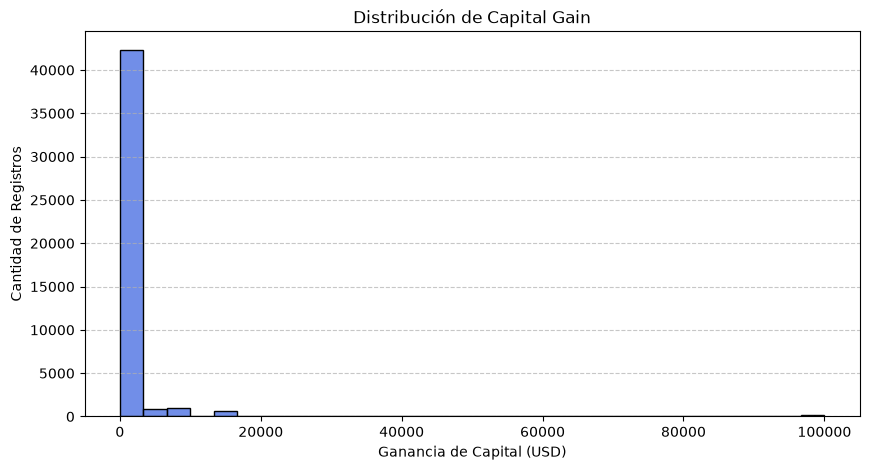

In [9]:
plt.figure(figsize=(10, 5))
# bins=30 divide el rango de ganancias en 30 barritas
sns.histplot(data['capital-gain'], bins=30, kde=False, color='royalblue')

plt.title('Distribución de Capital Gain')
plt.xlabel('Ganancia de Capital (USD)')
plt.ylabel('Cantidad de Registros')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [10]:
data['capital-gain'].value_counts()

capital-gain
0        41432
15024      498
7688       391
7298       351
99999      229
         ...  
7262         1
1731         1
22040        1
1639         1
2387         1
Name: count, Length: 121, dtype: int64

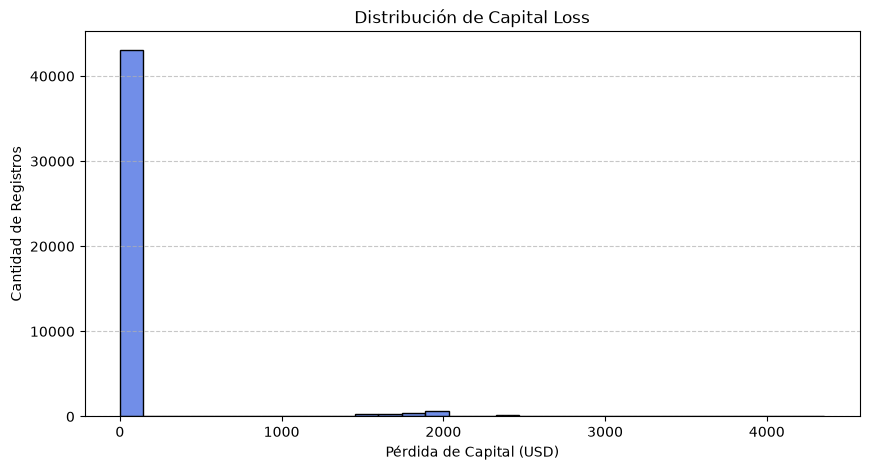

In [11]:
plt.figure(figsize=(10, 5))
# bins=30 divide el rango de ganancias en 30 barritas
sns.histplot(data['capital-loss'], bins=30, kde=False, color='royalblue')

plt.title('Distribución de Capital Loss')
plt.xlabel('Pérdida de Capital (USD)')
plt.ylabel('Cantidad de Registros')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [12]:
data['capital-loss'].value_counts()

capital-loss
0       43082
1902      294
1977      246
1887      228
2415       68
        ...  
4356        1
2080        1
419         1
155         1
2201        1
Name: count, Length: 97, dtype: int64

C:\Users\Urano\AppData\Local\Temp\ipykernel_15724\2101627954.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, ax=axes[i], palette='Set2')
C:\Users\Urano\AppData\Local\Temp\ipykernel_15724\2101627954.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, ax=axes[i], palette='Set2')
C:\Users\Urano\AppData\Local\Temp\ipykernel_15724\2101627954.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, ax=axes[i], palette='Set2')
C:\Users\Urano\AppData\Local\Temp\ipykernel_15724\2101627954.py:

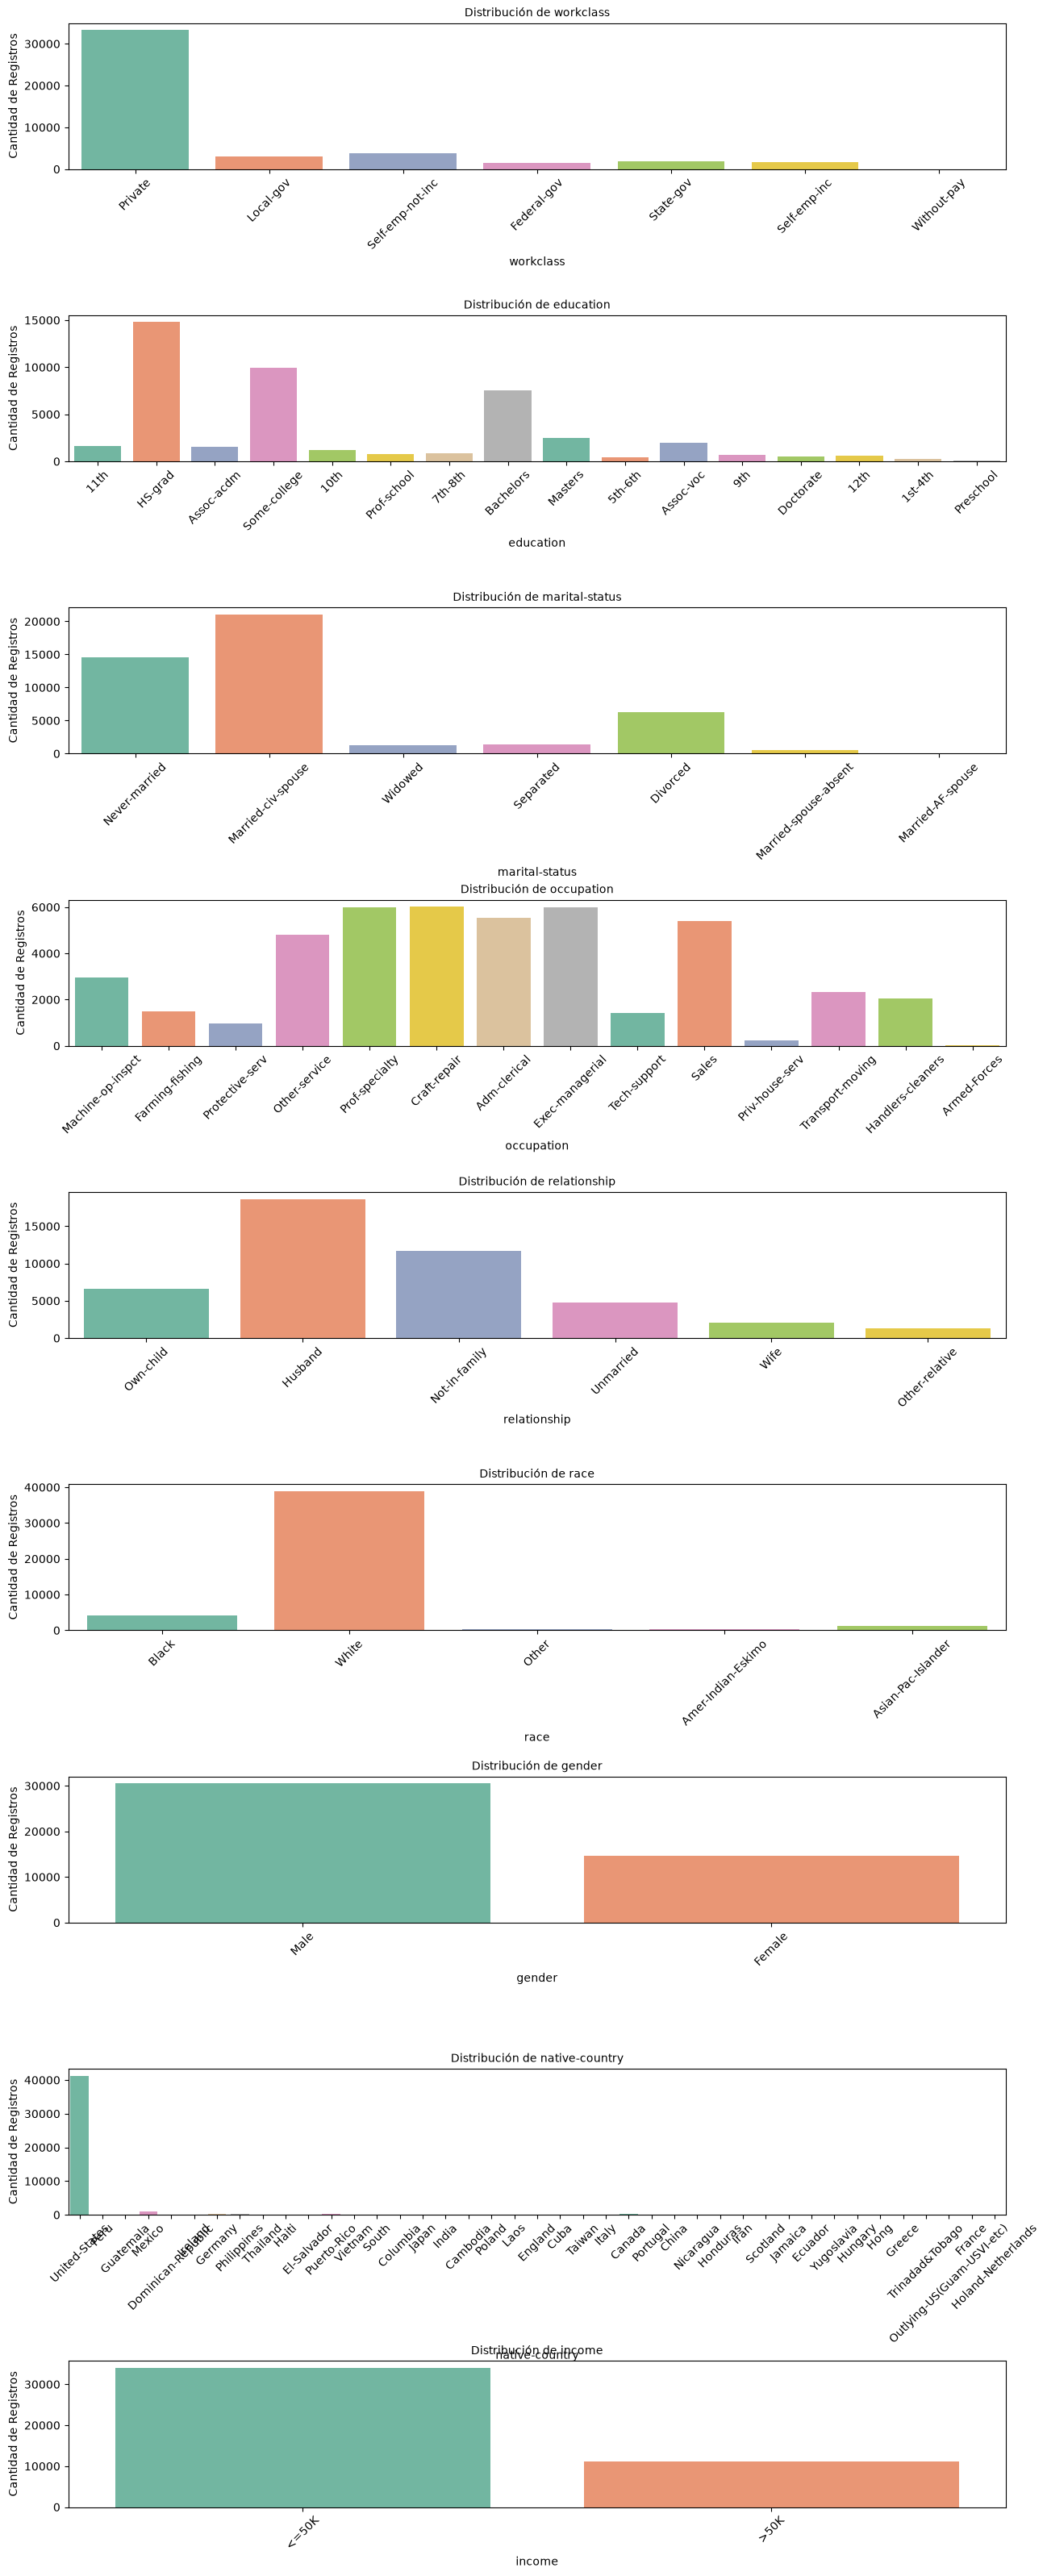

In [13]:
fig, axes = plt.subplots(nrows= 9, ncols=1, figsize=(15, 40))
fig.subplots_adjust(hspace=1)

for i, col in enumerate(columns_cat):
    sns.countplot(x=col, data=data, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribución de {col}', fontsize=10)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Cantidad de Registros', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

**Observaciones:**
- Las variables "race", "gender" no son significativas, y mancharian la reputación de la empresa a pesar de que es un dato de color la diferencia salarial en aquellas personas con ingresos >50K. -Eliminación-

In [14]:
"Eliminación de columnas irrelevantes"
data = data.drop("race", axis=1)
data = data.drop("gender", axis=1)
data.info()

<class 'pandas.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              45222 non-null  int64
 1   workclass        45222 non-null  str  
 2   fnlwgt           45222 non-null  int64
 3   education        45222 non-null  str  
 4   educational-num  45222 non-null  int64
 5   marital-status   45222 non-null  str  
 6   occupation       45222 non-null  str  
 7   relationship     45222 non-null  str  
 8   capital-gain     45222 non-null  int64
 9   capital-loss     45222 non-null  int64
 10  hours-per-week   45222 non-null  int64
 11  native-country   45222 non-null  str  
 12  income           45222 non-null  str  
dtypes: int64(6), str(7)
memory usage: 4.8 MB


Valor p de la prueba: 0.0
Las variables están fuertemente relacionadas.


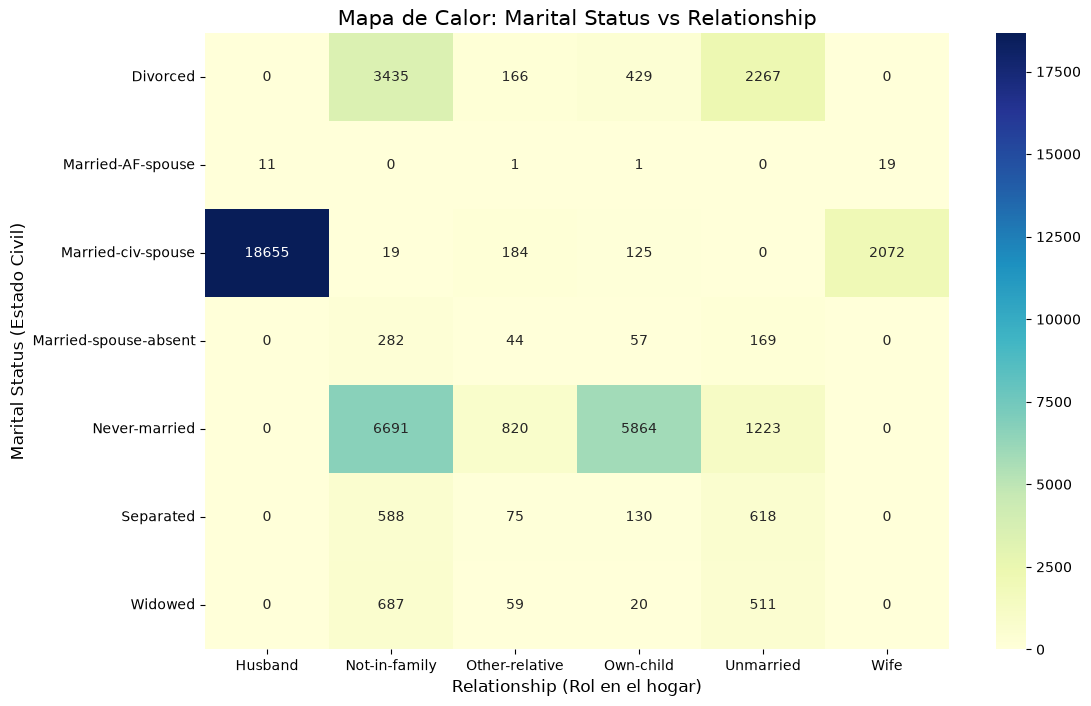

In [15]:
#Colinealidad entre -marital-status y relationship-
tabla_cruzada = pd.crosstab(data['marital-status'], data['relationship'])

# Aplicamos Chi-cuadrado
chi2, p, dof, ex = chi2_contingency(tabla_cruzada)
#Al tener variables categoricas puedo aplicar chi cuadrado y no correlación con pearson

print(f"Valor p de la prueba: {p}")
if p < 0.05:
    print("Las variables están fuertemente relacionadas.")

# 2. Creación del gráfico
plt.figure(figsize=(12, 8))
sns.heatmap(tabla_cruzada, annot=True, fmt='d', cmap='YlGnBu', cbar=True)

plt.title('Mapa de Calor: Marital Status vs Relationship', fontsize=15)
plt.xlabel('Relationship (Rol en el hogar)', fontsize=12)
plt.ylabel('Marital Status (Estado Civil)', fontsize=12)

plt.show()

Valor p de la prueba: 0.0
Las variables están fuertemente relacionadas.


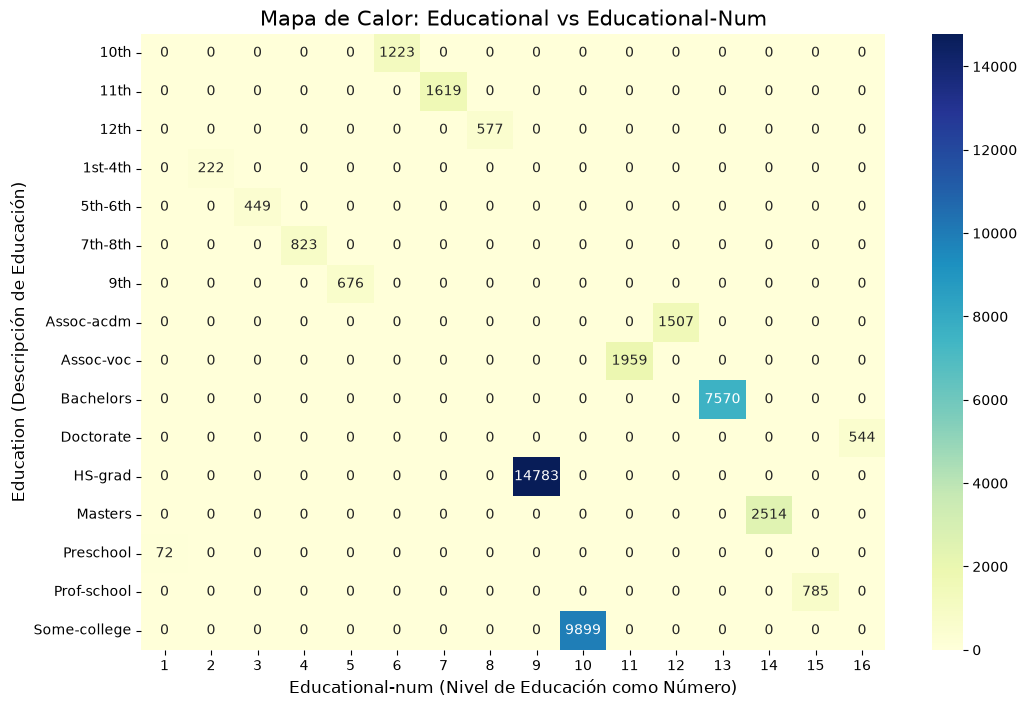

In [16]:
#Colinealidad entre -educational-num y education-
tabla_cruzada = pd.crosstab(data['education'], data['educational-num'])

# Aplicamos Chi-cuadrado
chi2, p, dof, ex = chi2_contingency(tabla_cruzada)
#Al tener variables categoricas puedo aplicar chi cuadrado y no correlación con pearson

print(f"Valor p de la prueba: {p}")
if p < 0.05:
    print("Las variables están fuertemente relacionadas.")

# 2. Creación del gráfico
plt.figure(figsize=(12, 8))
sns.heatmap(tabla_cruzada, annot=True, fmt='d', cmap='YlGnBu', cbar=True)

plt.title('Mapa de Calor: Educational vs Educational-Num', fontsize=15)
plt.xlabel('Educational-num (Nivel de Educación como Número)', fontsize=12)
plt.ylabel('Education (Descripción de Educación)', fontsize=12)

plt.show()

**Observación:**
 - Education: Alta multicolinealidad con Educational-num, para evitar errores de interpretación, ya que 4 corresponde a 7th-8th y así sucesivamente, elimino "Educational-num"
 - Marital-status_ Alta multicolinealidad con Relationship, se eliminará relationship.
 - La columna fnlwgt es irrelevante para el problema presentado, ya que solo se incluyen a los clientes de la empresa.

In [17]:
#Eliminación de columnas con Información Redundante

data = data.drop("educational-num", axis=1)
data = data.drop("relationship", axis=1)
data.info()

<class 'pandas.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             45222 non-null  int64
 1   workclass       45222 non-null  str  
 2   fnlwgt          45222 non-null  int64
 3   education       45222 non-null  str  
 4   marital-status  45222 non-null  str  
 5   occupation      45222 non-null  str  
 6   capital-gain    45222 non-null  int64
 7   capital-loss    45222 non-null  int64
 8   hours-per-week  45222 non-null  int64
 9   native-country  45222 non-null  str  
 10  income          45222 non-null  str  
dtypes: int64(5), str(6)
memory usage: 4.1 MB


In [18]:
#Eliminación de fnlwgt

data= data.drop("fnlwgt", axis=1)
data.info()

<class 'pandas.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             45222 non-null  int64
 1   workclass       45222 non-null  str  
 2   education       45222 non-null  str  
 3   marital-status  45222 non-null  str  
 4   occupation      45222 non-null  str  
 5   capital-gain    45222 non-null  int64
 6   capital-loss    45222 non-null  int64
 7   hours-per-week  45222 non-null  int64
 8   native-country  45222 non-null  str  
 9   income          45222 non-null  str  
dtypes: int64(4), str(6)
memory usage: 3.8 MB


In [20]:
# - ELIMINACIÓN DE OBSERVACIONES "Without-pay", CLIENTES SIN INGRESOS DESCARTADOS
data.drop(data[data['workclass'] == 'Without-pay'].index, inplace=True)
data.info()

<class 'pandas.DataFrame'>
Index: 45201 entries, 0 to 48841
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             45201 non-null  int64
 1   workclass       45201 non-null  str  
 2   education       45201 non-null  str  
 3   marital-status  45201 non-null  str  
 4   occupation      45201 non-null  str  
 5   capital-gain    45201 non-null  int64
 6   capital-loss    45201 non-null  int64
 7   hours-per-week  45201 non-null  int64
 8   native-country  45201 non-null  str  
 9   income          45201 non-null  str  
dtypes: int64(4), str(6)
memory usage: 3.8 MB


In [21]:
#ELIMINACIÓN DE  "Yugoslavia"- PAÍS NO EXISTENTE ACTUALMENTE
data.drop(data[data['native-country'] == 'Yugoslavia'].index, inplace=True)
data.info()

<class 'pandas.DataFrame'>
Index: 45178 entries, 0 to 48841
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             45178 non-null  int64
 1   workclass       45178 non-null  str  
 2   education       45178 non-null  str  
 3   marital-status  45178 non-null  str  
 4   occupation      45178 non-null  str  
 5   capital-gain    45178 non-null  int64
 6   capital-loss    45178 non-null  int64
 7   hours-per-week  45178 non-null  int64
 8   native-country  45178 non-null  str  
 9   income          45178 non-null  str  
dtypes: int64(4), str(6)
memory usage: 3.8 MB


In [ ]:
#ELIMINACIÓN DE FILAS REPETIDAS

print(f"Tamaño del set antes de eliminar filas repetidas: {data.shape}")
data.drop_duplicates(inplace=True)
print(f"Tamaño del set después de eliminar filas repetidas: {data.shape}")

Tamaño del set antes de eliminar filas repetidas: (45178, 10)
Tamaño del set después de eliminar filas repetidas: (34997, 10)


*OBSERVACIÓN:*  
    Se observó una eliminación de más de 10.000 observaciones repetidas, para mitigar riesgos y evitar asignaciones redundantes de presupuesto sobre un mismo perfil, se procedió a eliminar los duplicados exactos.

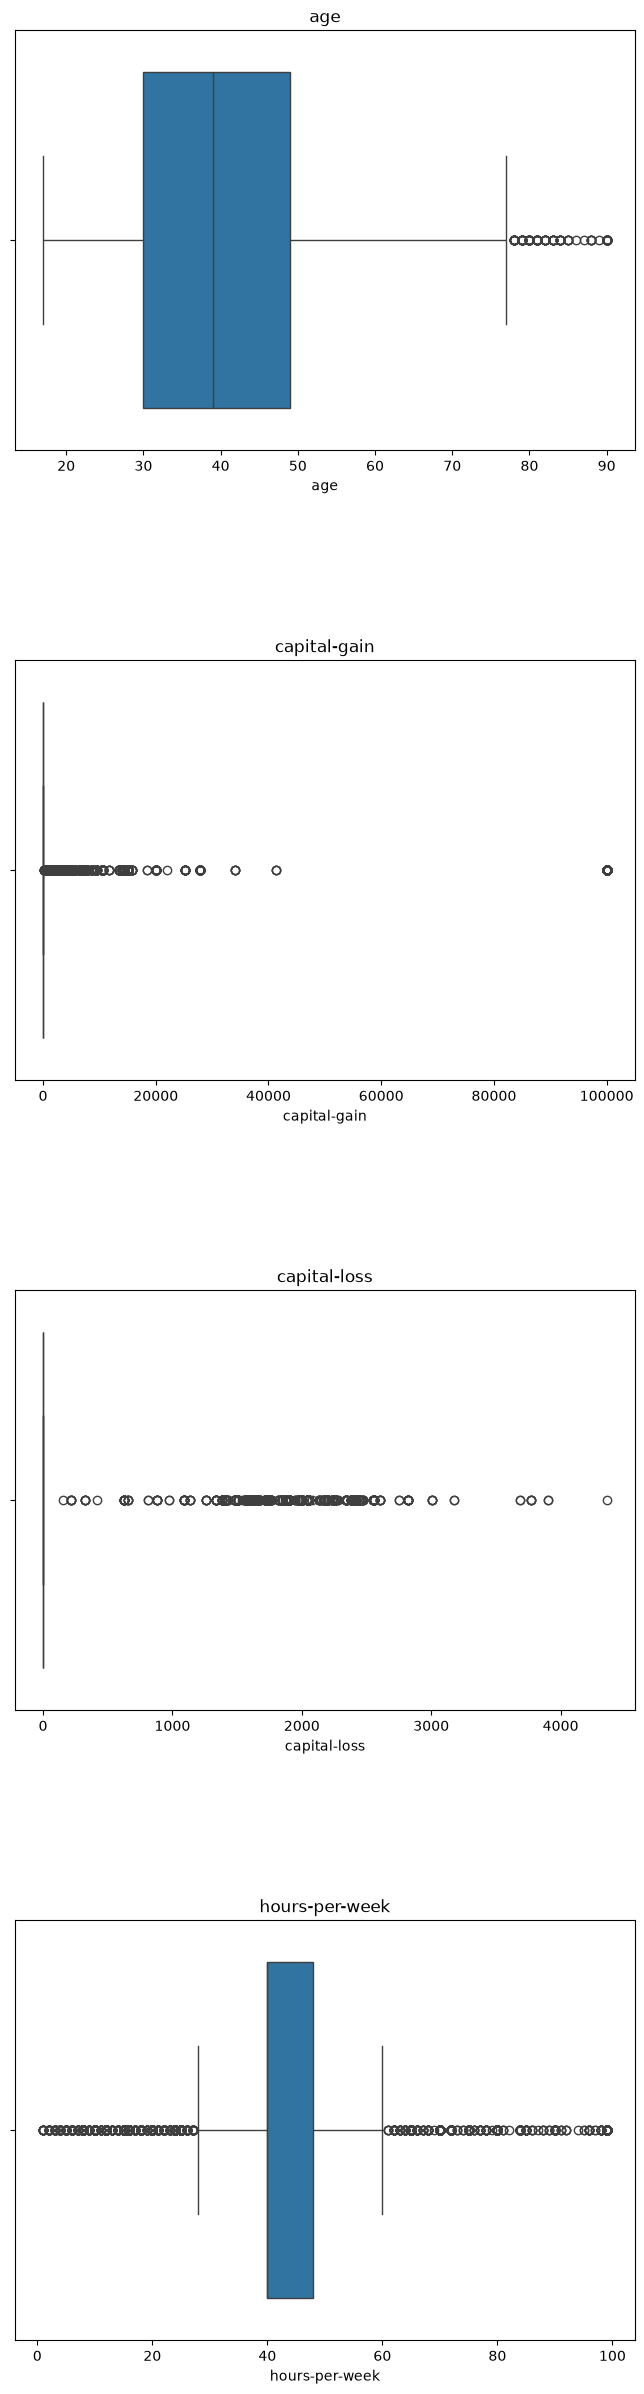

In [24]:
#Visualización de valores extremos en variables numéricas

col_num = ["age", "capital-gain", "capital-loss", "hours-per-week"]

fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(8, 30))
fig.subplots_adjust(hspace=0.5)

for i, col in enumerate(col_num):
    sns.boxplot(x=data[col], data=data, ax=ax[i])
    ax[i].set_title(col)

*Observación:*
 - Se detectan valores muy altos en Hours-per-week, aún que pueden ser comunes para algunos tipos de clientes.

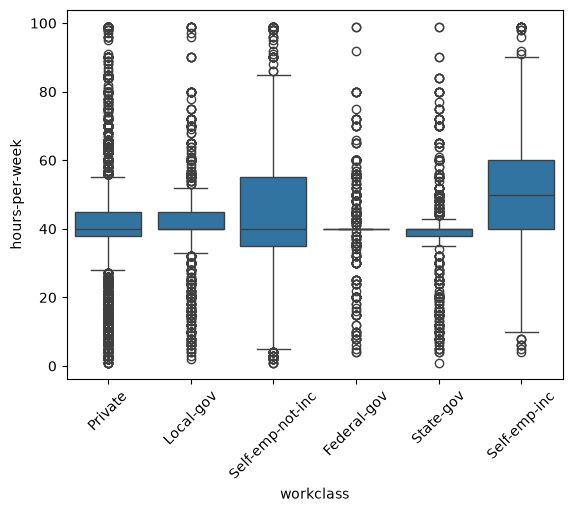

In [25]:
#Comparación de variable "Hours-per-week" en base a la variable "Workclass"
sns.boxplot(x='workclass', y='hours-per-week', data=data)
plt.xticks(rotation=45)
plt.show()

*Observación:*
  - En los puestos gubernamentales podemos ver que la mayor carga horaria se encuentra concentrada en las 40 hs, por lo que los outliers que superan las 70 horas semanales son con certeza errores o casos excepcionales por lo que se eliminarán.
  - A los datos del sector privado, para no terminar con una gran perdida de datos se les pondrá un capping con un limite superior de 80 horas semanales.

In [26]:
# 1. Filtramos y eliminamos los outliers ridículos del sector público ( > 70 horas)
sectores_publicos = ['Local-gov', 'Federal-gov', 'State-gov']
filtro_gobierno_extremo = (data['workclass'].isin(sectores_publicos)) & (data['hours-per-week'] > 70)
data = data[~filtro_gobierno_extremo]

# 2. Para el resto de los sectores (Private, Self-emp, etc.), limitamos el tope a 80 horas (Capping)
data['hours-per-week'] = data['hours-per-week'].clip(upper=80)

data.info()

<class 'pandas.DataFrame'>
Index: 34908 entries, 0 to 48837
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             34908 non-null  int64
 1   workclass       34908 non-null  str  
 2   education       34908 non-null  str  
 3   marital-status  34908 non-null  str  
 4   occupation      34908 non-null  str  
 5   capital-gain    34908 non-null  int64
 6   capital-loss    34908 non-null  int64
 7   hours-per-week  34908 non-null  int64
 8   native-country  34908 non-null  str  
 9   income          34908 non-null  str  
dtypes: int64(4), str(6)
memory usage: 2.9 MB


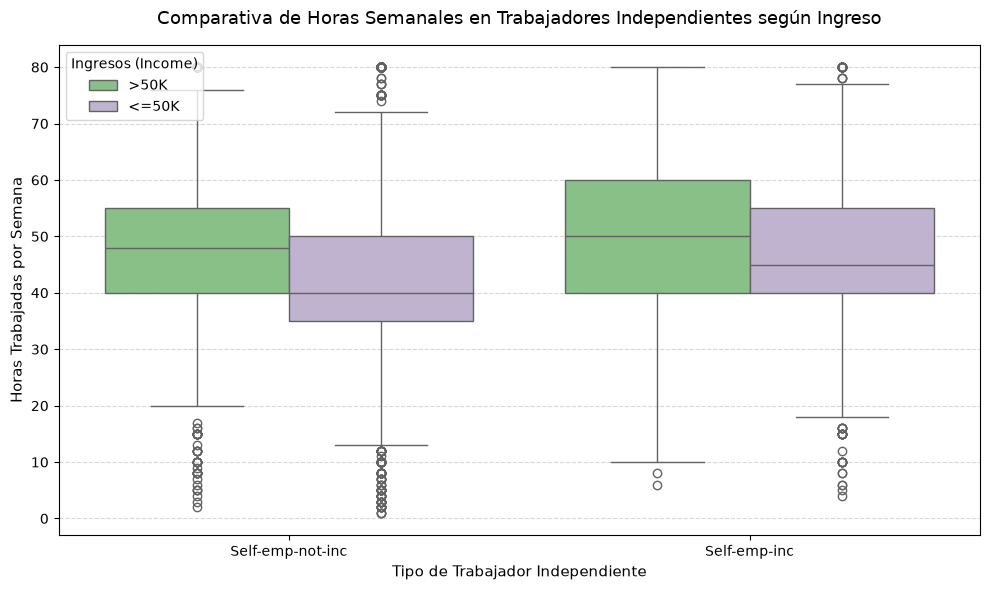

In [ ]:
#COMPARACIÓN DE HORAS SEMANALES EN TRABAJADORES INDEPENDIENTES SEGÚN INGRESO
independientes = data[data["workclass"].isin(["Self-emp-not-inc", "Self-emp-inc"])]

plt.figure(figsize=(10, 6))
sns.boxplot(x="workclass", y="hours-per-week", hue="income", data=independientes,
    palette="Accent",)

plt.title(
    "Comparativa de Horas Semanales en Trabajadores Independientes según Ingreso", fontsize=13, pad=15,)
plt.xlabel("Tipo de Trabajador Independiente", fontsize=11)
plt.ylabel("Horas Trabajadas por Semana", fontsize=11)
plt.legend(title="Ingresos (Income)", loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

*Observaciones:*
 - No hay registros con 0 hs de trabajo
 - Empleados independientes con empresas registadas, ingresos altos y bajas horas semanales representan perfiles de clientes estrella para la empresa, ya que tienen un perfil extremadamente solido, con baja exposición al desgaste laboral y un patrimonio que respalda sus ingresos.


### Re-Categorización:
 - education: {Without-Hig-grad: preschool, 1-4th, 5-6th, 7-8th, 9th, 10th, 11th, 12th} {HS-grad: HS-grad} {some-college:some-college} {assoc-degree: assoc-voc, assoc-acdm} los demás permanecen tal cual (prof-school, masters, doctorate, bachelors)
 - native-country: Asia, North-Ame, South-Ame, Europe, CentralAme-Caribe, EEUU
 - Marital-status: {married: married-civ-spouse, married-spouse-absent y married-AF-spouse}, separated, never-married, divorced, widowed



In [ ]:
#Re-categorización de la variable "education"

mapa_educacion = {
    'Preschool': 'Without-HS-grad', '1st-4th': 'Without-HS-grad', 
    '5th-6th': 'Without-HS-grad', '7th-8th': 'Without-HS-grad', 
    '9th': 'Without-HS-grad', '10th': 'Without-HS-grad', 
    '11th': 'Without-HS-grad', '12th': 'Without-HS-grad',
    'Assoc-voc': 'assoc-degree', 'Assoc-acdm': 'assoc-degree'
}

# Aplicamos el reemplazo. Los que no están en el diccionario (bachelors, masters, etc.) quedan igual.
data['education'] = data['education'].replace(mapa_educacion)

# Verificamos cómo quedó la distribución
print(data['education'].value_counts())

education
HS-grad            10077
Some-college        7263
Bachelors           5892
Without-HS-grad     4983
assoc-degree        3179
Masters             2245
Prof-school          747
Doctorate            522
Name: count, dtype: int64


In [ ]:
#Re-categorización de la variable "native-country"

mapa_paises = {
    # North-America (excluyendo United-States)
    'Mexico': 'North-America', 'Canada': 'North-America', 
    'Outlying-US(Guam-USVI-etc)': 'North-America',
    
    # CentralAme-Caribe
    'Puerto-Rico': 'CentralAme-Caribe', 'El-Salvador': 'CentralAme-Caribe', 
    'Cuba': 'CentralAme-Caribe', 'Jamaica': 'CentralAme-Caribe', 
    'Dominican-Republic': 'CentralAme-Caribe', 'Guatemala': 'CentralAme-Caribe', 
    'Haiti': 'CentralAme-Caribe', 'Nicaragua': 'CentralAme-Caribe', 
    'Trinadad&Tobago': 'CentralAme-Caribe', 'Honduras': 'CentralAme-Caribe',
    
    # South-America
    'Columbia': 'South-America', 'Peru': 'South-America', 'Ecuador': 'South-America',
    
    # Asia (incluyendo South y Hong)
    'Philippines': 'Asia', 'India': 'Asia', 'China': 'Asia', 'South': 'Asia', 
    'Japan': 'Asia', 'Vietnam': 'Asia', 'Taiwan': 'Asia', 'Iran': 'Asia', 
    'Thailand': 'Asia', 'Hong': 'Asia', 'Cambodia': 'Asia', 'Laos': 'Asia',
    
    # Europe (excluyendo Yugoslavia. Ojo: corregido 'ireland' a 'Ireland' si viene con mayúscula)
    'Germany': 'Europe', 'England': 'Europe', 'Italy': 'Europe', 'Poland': 'Europe', 
    'Portugal': 'Europe', 'Greece': 'Europe', 'France': 'Europe', 'Ireland': 'Europe', 
    'ireland': 'Europe', 'Scotland': 'Europe', 'Hungary': 'Europe', 'Holand-Netherlands': 'Europe'
}

# Aplicamos el reemplazo directo en la columna
data['native-country'] = data['native-country'].replace(mapa_paises)

# Verificamos cómo quedó la distribución final incluyendo los nulos
print(data['native-country'].value_counts(dropna=False))

In [29]:
#Re-categorizacion de la variables "marital-status"

mapa_marital = {
    'Married-AF-spouse': 'Married', 'Married-spouse-absent': 'Married', 
    'Married-civ-spouse': 'Married'
}

# Aplicamos el reemplazo. Los que no están en el diccionario (bachelors, masters, etc.) quedan igual.
data['marital-status'] = data['marital-status'].replace(mapa_marital)

# Verificamos cómo quedó la distribución
print(data['marital-status'].value_counts())

marital-status
Married          17659
Never-married     9512
Divorced          5188
Separated         1313
Widowed           1236
Name: count, dtype: int64


# **ANÁLISIS EXPLORATORIO DE DATOS**

- Analisis de cada variable individualmente, univariado y bivariado


# HECHO EN POWER QUERY

  - Eliminación de nulos y columnas irrelevantes anteriormente planteadas acá
  - Education, Marital-status, Workclass con re-categorización
  - Eliminación de outliers en trabajadores gubernamentales con respecto a las hs semanales
  - Eliminación de Observaciones duplicadas

  Fijar: Las horas trabajadas por semana, y empezar a graficar y buscar relaciones que no busqué
